---

numbering: false

---

# 2.5. Lines, Planes, and Hyperplanes

Think of this section as a brief detour from the main storyline of the course. Here, I'll cover how to describe lines, planes, and hyperplanes in $\mathbb{R}^n$, and how they relate to our understanding of the span of a set of vectors from [Chapter 2.4](04-span-linear-independence.ipynb).

## Lines

We're very familiar with lines in $\mathbb{R}^2$. The line $y = 2x + 3$, in $\mathbb{R}^2$, is the set of all $(x, y)$ coordinates that satisfy the equation $y = 2x + 3$.

Let's kick things up a notch and consider lines in $\mathbb{R}^3$. **What is the equation of the** <span style="color: #004d40; font-weight: bold;">line below</span>?

In [18]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v = (2, -1, 3)

# Create the line spanned by v (all scalar multiples)
t = np.linspace(-2, 2, 100)
line_x = t * v[0]
line_y = t * v[1]
line_z = t * v[2]

fig = plot_vectors([((0, 0, 0), "#3d81f6", r"")], show_axis_labels=True, vdeltax=0.1)

# Add the line spanned by v to the 3D plot
fig.add_trace(
    go.Scatter3d(
        x=line_x,
        y=line_y,
        z=line_z,
        mode="lines",
        line=dict(color="rgba(0,77,64,0.6)", width=5),
        showlegend=False,
        hoverinfo="skip"
    )
)

# Draw small points at (0, 0, 0) and the tip of v
fig.add_trace(
    go.Scatter3d(
        x=[0, v[0]],
        y=[0, v[1]],
        z=[0, v[2]],
        mode="markers",
        marker=dict(size=4, color=["#222", "#222"]),
        showlegend=False,
        hoverinfo="skip"
    )
)

# Add annotations next to the two points: (0,0,0) and (2,-1,3)
fig.add_trace(
    go.Scatter3d(
        x=[0],
        y=[0],
        z=[0],
        mode="text",
        text=["(0, 0, 0)"],
        textposition="top right",
        showlegend=False,
        hoverinfo="skip"
    )
)
fig.add_trace(
    go.Scatter3d(
        x=[v[0]],
        y=[v[1]],
        z=[v[2]],
        mode="text",
        text=[f"({v[0]}, {v[1]}, {v[2]})"],
        textposition="top center",
        showlegend=False,
        hoverinfo="skip"
    )
)

fig.update_layout(
    scene_camera=dict(
        eye=dict(x=-1.2, y=2, z=1.2)
    ),
    scene=dict(
        xaxis=dict(range=[-4, 4]),
        yaxis=dict(range=[-4, 4]),
        zaxis=dict(range=[-6, 6])
    ),
)

fig.show()

As we saw in [Chapter 2.4](04-span-linear-independence.ipynb), the line shown above is the span of the vector $\color{#3d81f6}\vec v = \begin{bmatrix} 2 \\ -1 \\ 3 \end{bmatrix}$. It passes through the origin, $(0, 0, 0)$, and passes through the point $(2, -1, 3)$.

Ideally, we'd be able to express the line as a function

$$z = f(x, y)$$

as we did in the $\mathbb{R}^2$ case, where $y = f(x) = mx + b$.

Unfortunately, there is no way to express the lines in $\mathbb{R}^3$, or $\mathbb{R}^4$, or $\mathbb{R}^n$ for $n > 2$ as a simple function. Why not? If there were some formula for $z$ (the height of the line) in terms of $x$ and $y$, that would imply that we should be able to plug in **any** $x$ and **any** $y$ to get an output $z$. But, the line above only works for very specific combinations of $x$ and $y$. For instance, there's no point on the line above that has $x = 1$ and $y = 1$. Rather, when $x = 1$, $y$ is forced to be $-\frac{1}{2}$, and $z$ is forced to be $\frac{3}{2}$.

The key idea that I stressed in [Chapter 2.4](04-span-linear-independence.ipynb) is that **lines are 1-dimensional objects**, meaning that the location of any point on the line can be described using a single free variable.

So, the equation of the line above is

$$L = t\begin{bmatrix} 2 \\ -1 \\ 3 \end{bmatrix}, t \in \mathbb{R}$$

$t$ here is a free variable – sometimes called a parameter (though this term is confusing in the context of our course) – meaning we can set it to whatever we'd like. The line is the set of all points that can be reached by plugging in different values of $t$.

Since the line is really a set of points, I should have written it as

$$L = \{t\begin{bmatrix} 2 \\ -1 \\ 3 \end{bmatrix} \mid t \in \mathbb{R}\}$$

but I'll use the former notation for brevity. 

Equivalently, you can think of the line as three separate functions of $t$. Pick a $t$. Then, $L$ is

$$\begin{align*} x = 2t \\ y = -t \\ z = 3t \end{align*}$$

Drag the value of $t$ below to see how $t$ allows us to move along the line.

In [22]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v = (2, -1, 3)

# Create the line spanned by v (all scalar multiples)
t = np.linspace(-2, 2, 25)
line_x = t * v[0]
line_y = t * v[1]
line_z = t * v[2]

fig = plot_vectors([((0, 0, 0), "#3d81f6", r"")], show_axis_labels=True, vdeltax=0.1)

# Add the line spanned by v to the 3D plot
fig.add_trace(
    go.Scatter3d(
        x=line_x,
        y=line_y,
        z=line_z,
        mode="lines",
        line=dict(color="rgba(0,77,64,0.6)", width=5),
        showlegend=False,
        hoverinfo="skip"
    )
)

# Add a marker that moves along the line as t changes, controlled by a slider
t_slider = np.linspace(-2, 2, 25)
marker_x = t_slider * v[0]
marker_y = t_slider * v[1]
marker_z = t_slider * v[2]

# Create frames for the moving marker
frames = [
    go.Frame(
        data=[
            go.Scatter3d(
                x=[marker_x[i]],
                y=[marker_y[i]],
                z=[marker_z[i]],
                mode="markers",
                marker=dict(size=8, color="black"),
                showlegend=False,
                hoverinfo="skip"
            )
        ],
        name=str(round(t_slider[i], 2))
    )
    for i in range(len(t_slider))
]

# Find the index where t=0 to set as the default frame
default_t_index = np.argmin(np.abs(t_slider - 0))

# Add slider to control t, set default value to t=0
sliders = [
    {
        "steps": [
            {
                "method": "animate",
                "args": [
                    [str(round(t_slider[i], 2))],
                    {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}
                ],
                "label": f"t={round(t_slider[i],2)}"
            }
            for i in range(len(t_slider))
        ],
        "currentvalue": {"prefix": ""},
        "pad": {"t": 50},
        "active": default_t_index
    }
]

fig.frames = frames
fig.update_layout(
    scene_camera=dict(
        eye=dict(x=-1.2, y=2, z=1.2)
    ),
    sliders=sliders,
    scene=dict(
        xaxis=dict(range=[-5, 5]),
        yaxis=dict(range=[-5, 5]),
        zaxis=dict(range=[-8, 8])
    ),
    # Increase bottom margin to prevent axis ticks from being cut off
    margin=dict(l=0, r=0, t=0, b=130),
    width=650,
    height=600
)

# Show the marker at t=0 by default
fig.add_trace(
    go.Scatter3d(
        x=[0],
        y=[0],
        z=[0],
        mode="markers+text",
        marker=dict(size=8, color="#aaa"),
        showlegend=False,
        hoverinfo="skip",
        text=["at t = 0, line passes through (0, 0, 0)"],
        textposition="top right",
        textfont=dict(color="#333", size=12)
    )
)

fig.show()

The line $L$ above passes through the origin, since if we set $t = 0$, we get the point $(0, 0, 0)$. This matches what we'd expect out of the span of a single vector, since $0 {\color{#3d81f6}\vec v} = \vec 0$.

But how do we express a line that passes through some other fixed point that **isn't** the origin? Such a line might not be the span of a single vector, since the span of a single vector is always a line that passes through the origin. But, it's good to know how to think about lines in this more general form.

:::{note} Definition: Line

A **line** in $\mathbb{R}^n$ that passes through the point $\vec p_0$ and is parallel to the vector $\vec v$ can be described as:

$$L = \vec p_0 + t\vec v, t \in \mathbb{R}$$

This is sometimes called the **parametric form** of the line, since $t$ can be thought of as a parameter.
:::

The definition above is not specific to 2-dimensional or 3-dimensional space – it works in any $\mathbb{R}^n$. (Technically, I'm mixing the meaning of a point and a vector here, but as long as we remember that points describe positions and vectors describe directions, we should be fine.)

Note that the parametric form of a line is not unique! Since the parametric definition of a line depends on a "starting point" $\vec p_0$, we can pick any starting point we'd like. We can also scale the direction vector by any non-zero scalar. So, 

$$L_1 = \begin{bmatrix} 1 \\ 2 \end{bmatrix} + t \begin{bmatrix} -3 \\ 4 \end{bmatrix}, t \in \mathbb{R}$$

is the same line as

$$L_2 = \begin{bmatrix} -2 \\ 6 \end{bmatrix} + t \begin{bmatrix} 6 \\ -8 \end{bmatrix}, t \in \mathbb{R}$$

once you consider all possible values of $t$ in both cases.  (I know this is a little confusing, since plugging the same value of $t$ into $L_1$ and into $L_2$ will give you different points, but remember that $L_1$ and $L_2$ are sets, and so we need to consider all possible values of $t$.)

Below is a plot of $L_1$.

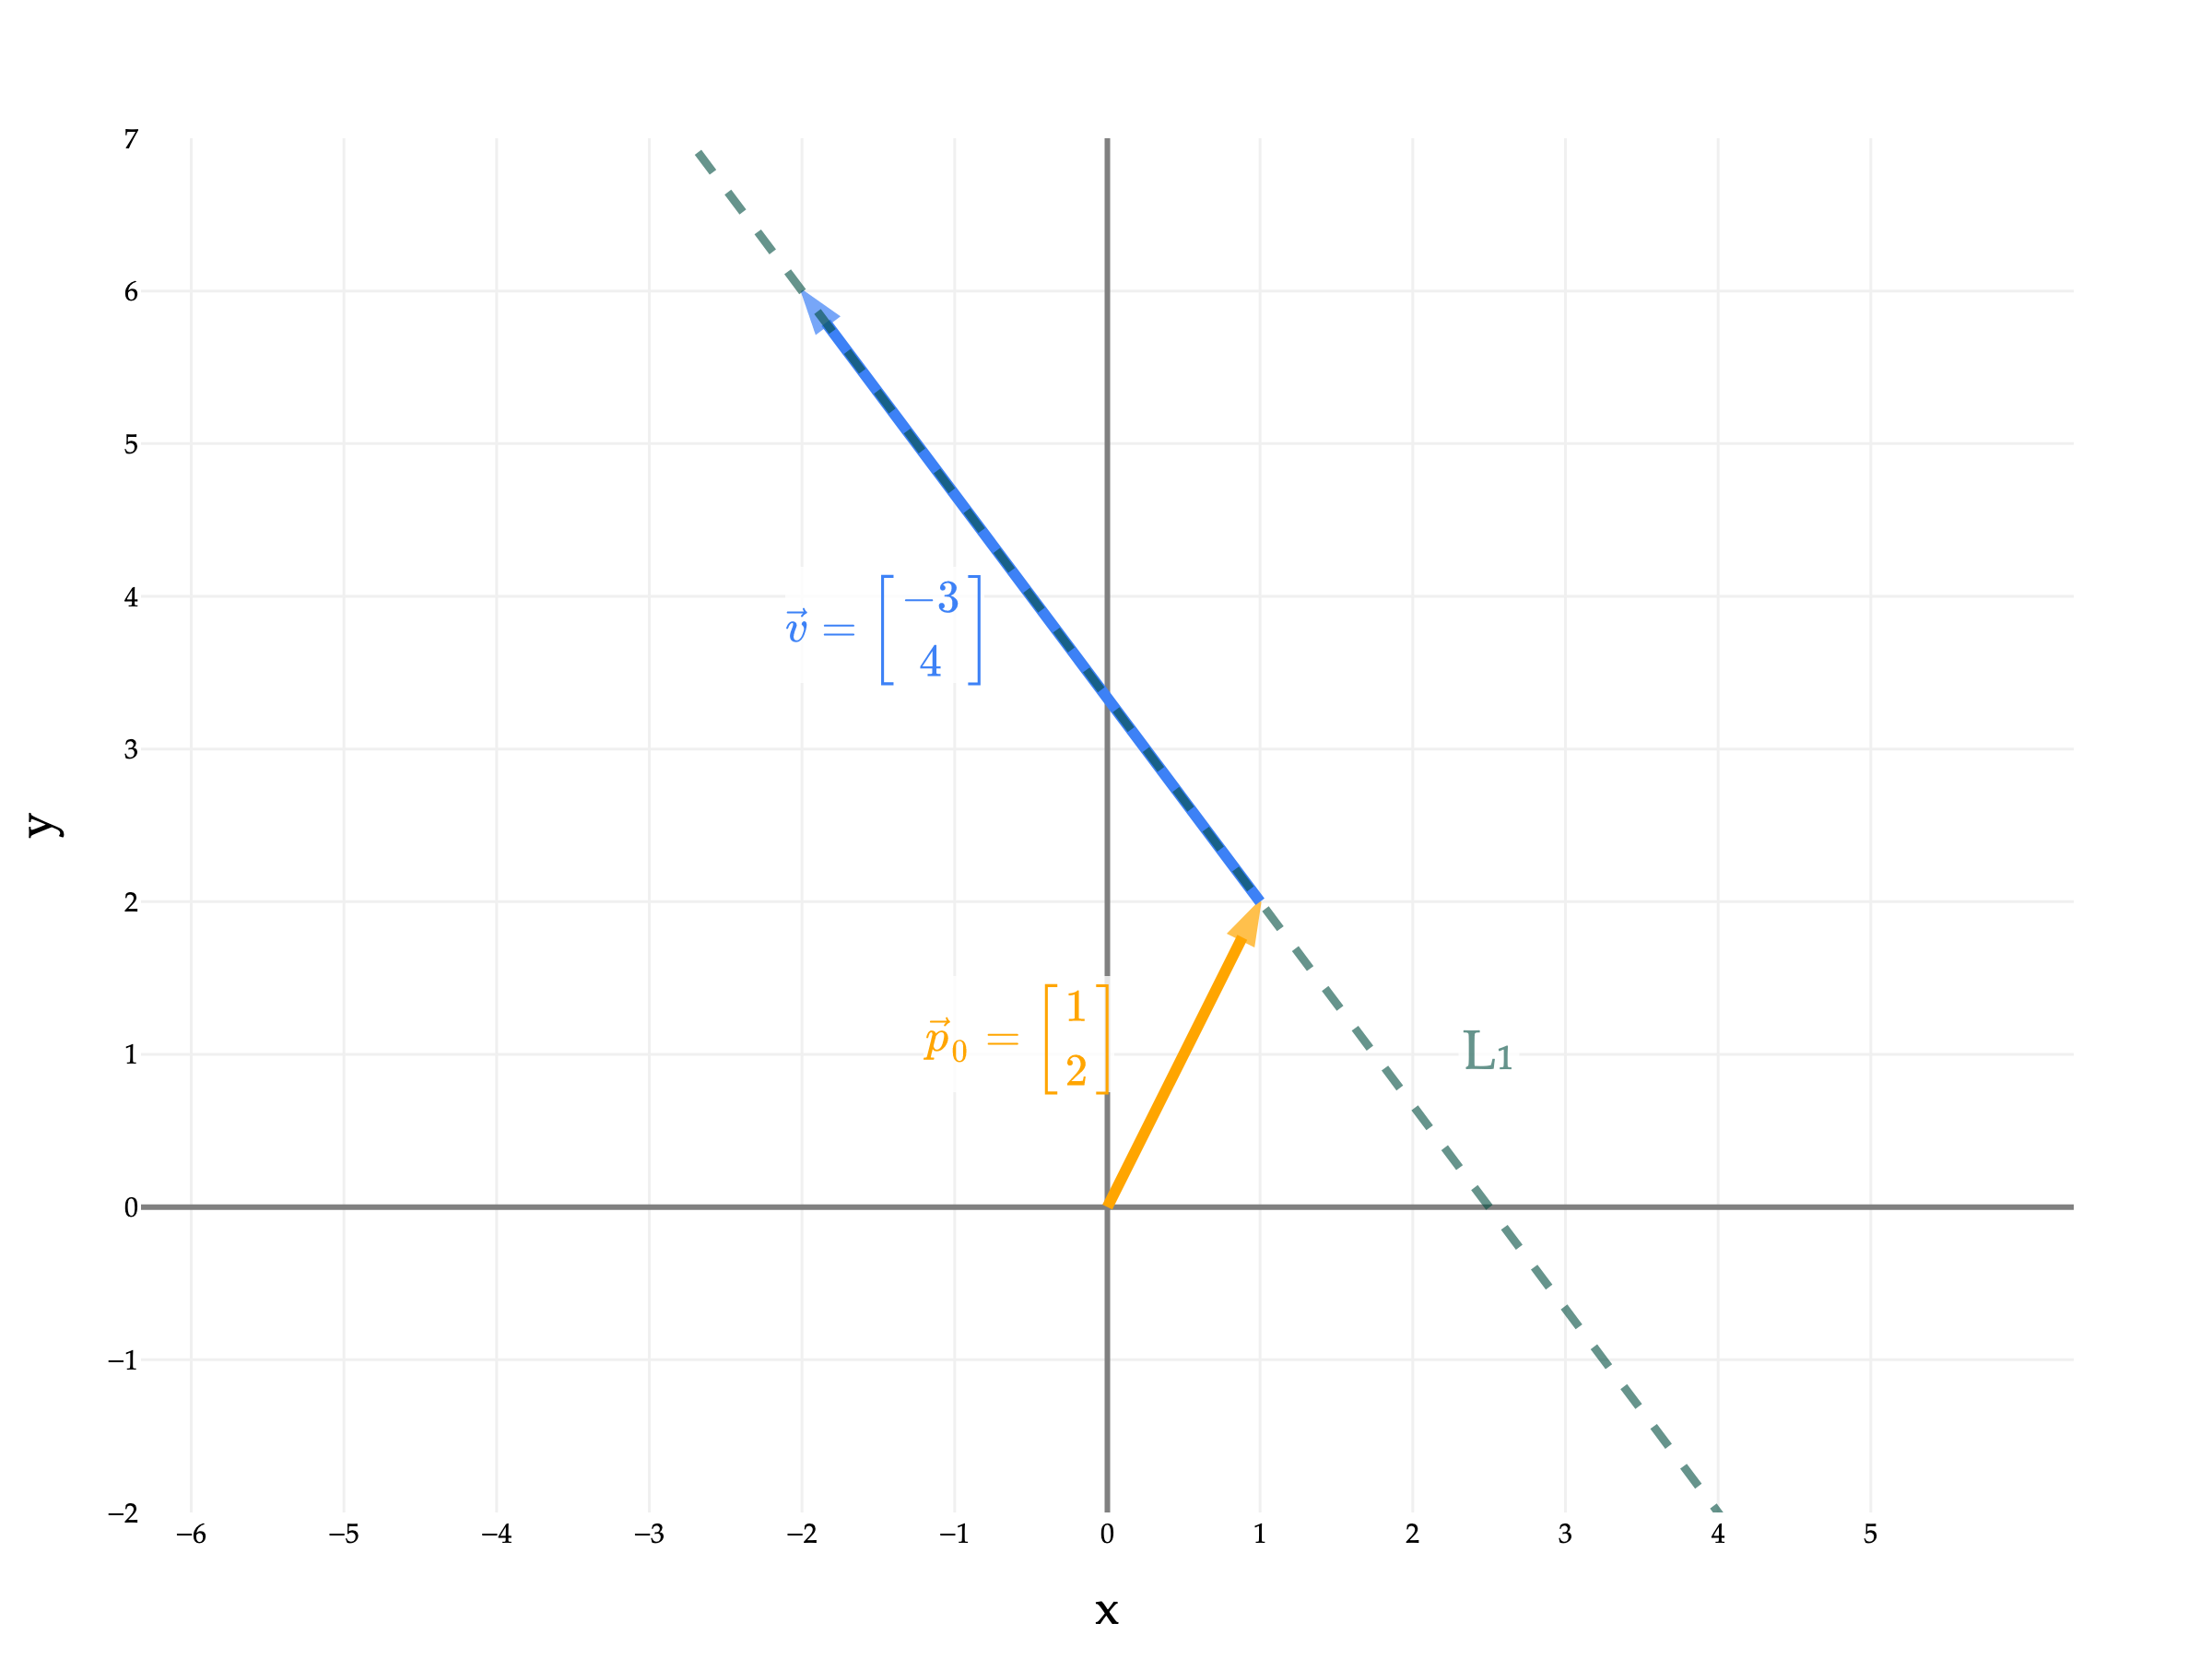

In [23]:
from utils import plot_vectors_non_origin

p0 = (1, 2)
v = (-3, 4)

vectors = [
    # ((start_coords, end_coords), color, label)
    (([0, 0], p0), "orange", r"$\vec p_0 = \begin{bmatrix} 1 \\ 2 \end{bmatrix}$"),
    ((p0, tuple(np.array(p0) + np.array(v))), "#3d81f6", r"$\vec v = \begin{bmatrix} -3 \\ 4 \end{bmatrix}$"),
]

fig = plot_vectors_non_origin(vectors, show_axis_labels=True, vdeltax=1.2)

# Focus the plot on x in [-2, 4]
t = np.linspace(-2, 2, 100)  # Solve for t so that x runs from -2 to 4
line_x = p0[0] + t * v[0]
line_y = p0[1] + t * v[1]

fig.add_trace(
    go.Scatter(
        x=line_x,
        y=line_y,
        mode="lines",
        line=dict(color="rgba(0,77,64,0.6)", width=3, dash="dash"),
        showlegend=False,
        hoverinfo="skip",
        zorder=0
    ),
)

# This annotation indicates the line represents all possible linear combinations of v alone
fig.add_annotation(
    x=1.5 * v[0] + 7,
    y=1.5 * v[1] - 5,
    text="L₁",
    showarrow=False,
    font=dict(size=20, color="rgba(0,77,64,0.6)"),
    bgcolor="rgba(255,255,255,0.8)"
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
    range=[-2, 7]
)

fig.update_xaxes(
    range=[-4, 4],
    tickvals=np.arange(-6, 6, 1)
)

fig.show(renderer='png', scale=3)

Reason about why $L_2$ is the same line as $L_1$ above.

The proceeding activities give you some practice with the parametric form of a line.

:::{tip} Activity 1
:class: dropdown
Write the line $y = -3x + 5$ in parametric form. There are multiple (infinitely many!) possible answers; give just one. 

:::{seealso} Solution
:class: dropdown

The line above passes through the point $(0, 5)$ and is parallel to the vector $\begin{bmatrix} 1 \\ -3 \end{bmatrix}$, since for every 1 unit we move in the $x$-direction, we move $-3$ units in the $y$-direction. So, the line is:

$$L = \begin{bmatrix} 0 \\ 5 \end{bmatrix} + t \begin{bmatrix} 1 \\ -3 \end{bmatrix}, t \in \mathbb{R}$$

To verify that we got the right line, let's plug in a few values of $t$ and verify that they match the equation $y = -3x + 5$.

- When $t = 0$, we get the point $(0, 5)$, and $-3(0) + 5 = 5$ ✅.
- When $t = 1$, we get the point $(1, 2)$, and $-3(1) + 5 = 2$ ✅.
- When $t = -10$, we get the point $(-10, 35)$, and $-3(-10) + 5 = 35$ ✅.

(We only need to check two points, since if two lines have the same two points, they must be the same line.)

:::

:::{tip} Activity 2
:class: dropdown

Find the equation of the line, in parametric form, of the line in $\mathbb{R}^4$ that passes through the points $(5, -1, 3, 2)$ and $(10, -2, 3, 0)$.

:::{seealso} Solution
:class: dropdown

We know one point on the line; we just need to find a direction vector. One way to do this is to subtract the coordinates of the two points:

$$\begin{bmatrix} 10 \\ -2 \\ 3 \\ 0 \end{bmatrix} - \begin{bmatrix} 5 \\ -1 \\ 3 \\ 2 \end{bmatrix} = \begin{bmatrix} 5 \\ -1 \\ 0 \\ -2 \end{bmatrix}$$

So, the line is:

$$L = \begin{bmatrix} 5 \\ -1 \\ 3 \\ 2 \end{bmatrix} + t \begin{bmatrix} 5 \\ -1 \\ 0 \\ -2 \end{bmatrix}, t \in \mathbb{R}$$

Plugging in $t = 0$ and $t = 1$ should give us the two points we know are on the line.

:::

:::{tip} Activity 3
:class: dropdown

Could the line you found in Activity 2 be described as the span of a single vector? Why or why not?

:::{seealso} Solution
:class: dropdown

**No**, because it doesn't pass through the origin, and the span of a single vector is always a line that passes through the origin.

Let's look at $L$ once more:

$$L = \begin{bmatrix} 5 \\ -1 \\ 3 \\ 2 \end{bmatrix} + t \begin{bmatrix} 5 \\ -1 \\ 0 \\ -2 \end{bmatrix}, t \in \mathbb{R}$$


Just by looking at the equation above, we don't know for a fact that it doesn't pass through the origin, $(0, 0, 0, 0)$. The fixed point that it is defined relative to, $(5, -1, 3, 2)$, is not the origin, but the origin might still be on the line if we pick the right value of $t$.

But, we can verify that that's not the case by plugging in $t = -1$, which gives us a 0 in the first two coordinates, but non-zero values in the other coordinates. At $t = -1$:

$$L = \begin{bmatrix} 5 \\ -1 \\ 3 \\ 2 \end{bmatrix} - 1 \begin{bmatrix} 5 \\ -1 \\ 0 \\ -2 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 3 \\ 4 \end{bmatrix}$$

There's no value of $t$ other than $-1$ such that $5 + t(5) = 0$, so no other value of $t$ will give us the point $(0, 0, 0, 0)$.

:::

---

## Planes

Lines are 1-dimensional objects, whether they exist in $\mathbb{R}^2$, or $\mathbb{R}^3$, or $\mathbb{R}^{47}$, or in general $\mathbb{R}^n$.

Similarly, planes are 2-dimensional objects.